# **Laboratorio 15: Redes Neuronales Convolucionales (CNN)**

Departamento de Ingeniería Biomédica

Universidad de los Andes

**IBIO-2340:** Fundamentos de Machine Learning

 **Nombres de los integrantes**


1.   Santiago Casasbuenas
2.   Juan Pablo Castro
3.   Ana Cristina Rodríguez

**Número del grupo**

9


# **Redes Neuronales Convolucionales**

> Las *CNN* son arquitecturas que explotan la **estructura espacial** de los datos de entrada a través de *conectividad local* y *parámetros compartidos* haciendo uso de *filtros aprendibles* que permiten construir *representaciones jerárquicas que mantienen una invarianza traslacional* con una significativa menor cantidad de parámetros que una ANN.

Esta capacidad de identificar patrones con jerarquía espacial permite que las *CNN* puedan ser utilizadas en varias aplicaciones:

* En Visión Artificial: Los patrones locales en los píxeles forman bordes y texturas que se combinan para dar lugar a objetos reconocibles.

* En Reconocimiento de Voz: Se basa en patrones que abarcan segmentos temporales cercanos para identificar fonemas y palabras.

* En redes de sensores: Se analizan correlaciones entre sensores físicamente próximos para comprender los patrones del entorno.

* En Imágenes Médicas: Su análisis depende del reconocimiento de patrones tisulares que se asocian con diferentes patologías.  


**1. Convolución en CNN**

La operación de convolución es fundamental en el funcionamiento y estructura de las CNN. Supongamos una *señal de entrada* $I$ en $2-D$ y un *filtro* $K$ (también llamado *kernel*) de tamaño $(m \times n)$, la convolución entre $I$ y $K$ se define como:

$$
S(i,j) = \sum_{m} \sum_{n} I(i + m, j + n) \cdot K(m, n) 
$$

Donde la *señal de salida* $S(i,j)$ se conoce como *feature map*. Note que si el filtro tiene cualquier tamaño mayor a $(1 \times 1)$ la operación de convolución reduce el tamaño de la señal de entrada.

La operación de convolución es una *transformación afín* (lo que simplificamos como "lineal" en ML) tal y como la suma ponderada de pesos en una ANN, por esta razón para permitir que los filtros **aprendan relaciones no-lineales** se añade una capa que aplica una función de activación sobre la *señal de salida*:

$$
I' = f(S(i,j)) = f\left(\sum_{m} \sum_{n} I(i + m, j + n) \cdot K(m, n) \right) 
$$

Esta función de activación se aplica sobre cada una de las posiciones de la señal $S$, de modo que $I'$ tiene el mismo tamaño y dimensión que $S$.

La naturaleza de la operación de convolución introduce dos dinámicas adicionales:

- *Stride*: Determina el número de posiciones que el filtro desplaza en cada paso al recorrer la señal de entrada. Un stride de $1$ implica que el filtro se mueve una posición a la vez, procesando regiones solapadas. Un stride mayor a $1$ hace que el filtro avance más posiciones entre operaciones, generando regiones sin solapamiento y produciendo un *feature map* de menor tamaño espacial. En general, a mayor valor de stride, menor es la dimensión de salida.

- *Padding*: Es una técnica que consiste en agregar filas y columnas adicionales alrededor de la señal de entrada (o feature map en capas posteriores) antes de aplicar la convolución. Su propósito principal es controlar la reducción espacial que produce el filtro. Lo más comun es añadir las posiciones respectivas con valor $0$ (*Zero-padding*).

El valor de *stride* y el uso de *padding* hacen parte de los hiperparámetros de esta arquitectura.

**2. Capa de Pooling**

Después de la operación de convolución (con su stride y padding) y su correspondiente función de activación no-lineal, suele añadirse una capa de Pooling. Su función es extraer la información más relevante del *feature map* generado y resumirla en una señal de menor dimensión, típicamente tomando el valor máximo (**max pooling**) o el promedio (**average pooling**) en regiones locales, de manera análoga a una convolución pero sin pesos aprendibles. Reduce el costo computacional y evita el sobreajuste (introduce invarianza ante pequeñas traslaciones).

La capa de *Pooling* se añade de forma independiente a la capa de *Activación* y aunque lo más común es añadirla después, no hay ninguna restricción que impida añadirla antes. Debido a que opera como una ventana deslizante (de la misma forma en que operan los filtros) también puede establecerse un valor de *stride* para la capa de *Pooling* y un tamaño de ventana, lo que aumenta el número de hiperparámetros de la arquitectura.

Es importante resaltar que:

>  La capa de Pooling no tiene parámetros aprendibles; es una operación fija. Los únicos parámetros de una CNN son los valores de los filtros.

**3. Capas Convolucionales**

Las *CNN* se forman con la unión consecutiva de capas convolucionales, cada una compuesta por:


- **Etapa de Convolución:** Es la primera capa, toma la señal de entrada y aplica la operación de convolución, con el *stride* y *padding* definidos.
- **Etapa de Activación (o Detección)**: Usualmente la capa intermedia, recibe el *feature map* y aplica la función de activación no-lineal permitiendo la identificación de patrones complejos.
- **Etapa de Pooling**: Usualmente la capa final, reduce la dimensión espacial del *feature map* conservando la información más relevante mediante una función de agregación. Actúa como un regularizador interno.

Algunos autores no agrupan estas operaciones al interior de una única capa sino que las consideran capas completamente independientes, en ese sentido, la arquitectura de una *CNN* se construye con la composición de las capas de Convolución, de Detección y de Pooling.


<div style="text-align: center;">
    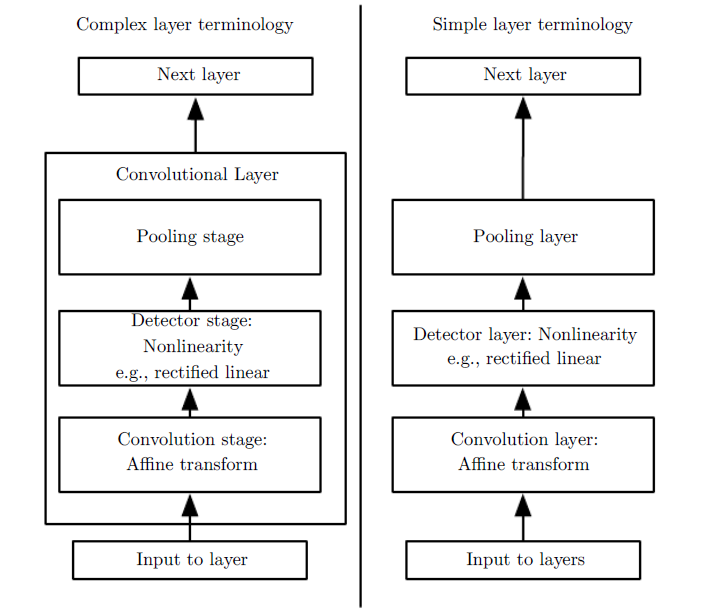

<p> Notación de capas convolucionales. Tomado de Deep Learning - Ian Goodfellow, Yoshua Bengio y Aaron Courville </p>

</div>

**3. ¿Cómo se entrena una Red Neuronal Convolucional?**

Las *CNN* se entrenan de forma análoga a las *ANN*, utilizando el algoritmo de **Backpropagation** para calcular la contribución de cada parámetro al error de predicción (en este caso, los valores numéricos dentro de cada filtro). Posteriormente, los parámetros se actualizan mediante un paso de **Gradient Descent**.

**Diferencias clave respecto a las ANN**:

- Debido a que un mismo filtro se aplica en múltiples posiciones espaciales (pesos compartidos), su gradiente se obtiene sumando las contribuciones de todas esas posiciones.

- La propagación del error hacia la entrada requiere una operación de convolución transpuesta o de correlación cruzada con filtros rotados.

- Inicialización de filtros: Se inicializan con valores aleatorios, pero esta aleatoriedad sigue distribuciones específicas que dependen de la función de activación utilizada: Para ReLU y sus variantes (las más comunes en CNN): *He initialization* y para funciones sigmoidales o tanh: *Xavier/Glorot*.


# **Contexto del problema**

En el laboratorio anterior entrenamos un modelo de clasificación para distinguir señas estáticas en **LSC** haciendo uso del modelo *HandLandmaker* de **Google MediaPipe** para extraer las coordenadas de cada punto anatómico de la mano en la seña y usarlas como características, lo cual facilito en gran medida el proceso de entrenamiento y nos proporcionó excelentes resultados.

En este laboratorio vamos a considerar otra aproximación para resolver el problema. Aprovechando el hecho de que las *CNNs* están diseñadas para aprender representaciones jerárquicas directamente a partir de imágenes, sin necesidad de definir manualmente las características relevantes, vamos a entrenar una CNN que puedar aprender automáticamente:

* Bordes y contornos de la mano.

* Configuraciones globales de los dedos.

* Relaciones espaciales complejas que no están explícitas en los landmarks.

Y utilice estas características aprendidas para clasificar adecuadamente las señas haciendo uso de una *ANN*. Así podremos comparar ambas experiencias y aprender a usar este tipo de arquitectura.

En primer lugar importamos las librerías:

In [17]:
# Si usas Google Colab, descomenta esta celda y ejecutala para descomprimir las carpetas
# !unzip -q LSC_dataset_CNN.zip

In [18]:
# Librerias de uso general
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modelos de Machine Learning
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Modelos de Deep Learning
import tensorflow as tf
from tensorflow import keras

Establecemos unos parámetros globales e importamos las imágenes que previamente se han separado en un conjunto de entrenamiento, validación y prueba siguiendo los porcentajes $(70\%, 20\%, 10\%)$ respectivamente:

In [19]:
# Parámetros globales de la imagen

# Reducimos el número de pixeles para reducir el consumo de memoria
# No es crítico porque los detalles a capturar no son locales, sino generales
IMG_SIZE = 200 

# Imagen RGB
IMG_CHANNEL = 3 

# Diccionario para mapear clases y etiquetas
CLASS_LABEL_DICT = {}

# Configuración general de la tarea
N_CLASSES = 0

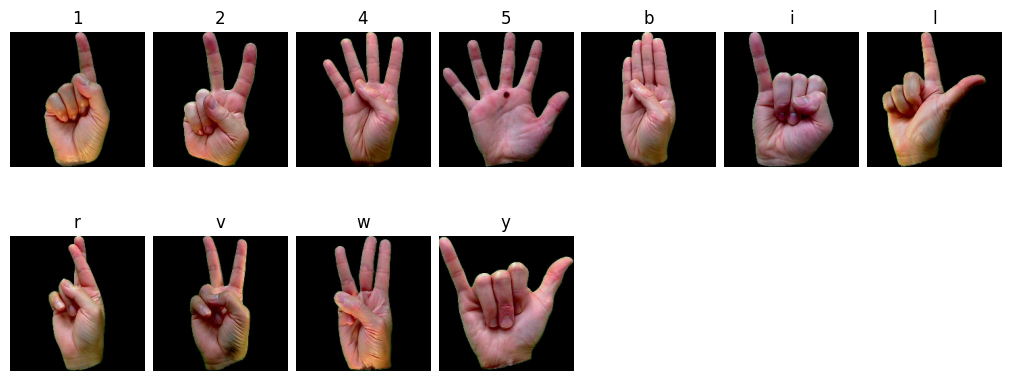

In [20]:
#Visualizamos una imagen de cada categoria en el conjunto de datos
data_dir = "LSC_dataset_CNN"
data_dir_train = os.path.join(data_dir,"train")
data_dir_val = os.path.join(data_dir,"val")
data_dir_test = os.path.join(data_dir,"test")

lsc_categories = sorted(os.listdir(data_dir_train))

# Se confirma el número de clases con la información del conjunto de satos
N_CLASSES = len(lsc_categories)

# Configuramos el grafico usando matplotlib, agregando los ejes de forma dinámica
fig = plt.figure(figsize=(10,8), layout="constrained") # Ancho x alto
# Cantidad de columnas a agregar
columns_figure = int(N_CLASSES/3)+1

# Aprovechamos el ciclo para contar el número de imagenes de cada clase
image_class_count = {}

for index, category in enumerate(lsc_categories):
   folder_category = os.path.join(data_dir_train, category)
   
   # Contamos el número total de imágenes y usamos el nombre de la clase como llave
   image_class_count[category] = len(os.listdir(folder_category))

   # Recuperamos la primera imagen de cada categoria
   image_file = os.listdir(folder_category)[0] 
   img_path = os.path.join(folder_category, image_file)
   img = keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE,IMG_SIZE)) # Se reduce la resolución, se interpolan los píxeles 
   ax = fig.add_subplot(columns_figure,7, index+1) # add_subplots se indexa desde 1 (a diferencia de subplots())
   ax.set_axis_off()
   ax.imshow(img)
   ax.set_title(category)


Para mejorar la robustez del modelo implementamos *data augmentation* en el conjunto de entrenamiento. Asi mismo, normalizamos cada imagen en los tres conjuntos: 

In [21]:
# Implementamos una función sencilla que orienta la creación de un dataframe para cada conjunto de datos
def create_dataframe_from_directory(directory):
    filepaths = []
    labels = []
    for category in sorted(os.listdir(directory)):
        category_path = os.path.join(directory, category)
        if os.path.isdir(category_path):
            for img_file in os.listdir(category_path):
                filepaths.append(os.path.join(category_path, img_file))
                labels.append(category)
    return pd.DataFrame({'filepath': filepaths, 'label': labels})

# Creamos Dataframes para cada conjunto de datos
train_df = create_dataframe_from_directory(data_dir_train)
val_df = create_dataframe_from_directory(data_dir_val)
test_df = create_dataframe_from_directory(data_dir_test)

# Creamos un generador de Data Augmentation para el conjunto de entrenamiento
train_generator = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

# Generador para validación y test (solo reescala)
test_val_generator = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# Creación de generadores a partir de los DataFrames
train_ = train_generator.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=32,
)
val_ = test_val_generator.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=32, shuffle=False
)
test_ = test_val_generator.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=32, shuffle=False
)

Found 538 validated image filenames belonging to 11 classes.
Found 154 validated image filenames belonging to 11 classes.
Found 78 validated image filenames belonging to 11 classes.


A continuación definimos un modelo de Red Neuronal Convolucional para clasificación multiclase con Keras. Consideramos una capa convolucional de $4$ filtros  con función de activación *ReLu* y una etapa de *Max Pooling*. Los filtros son de tamaño $(3 \times 3)$ mientras la ventana de Pooling es de tamaño $(2 \times 2)$. En la capa se mantiene un *stride* de $1$ y no se realiza *padding*:

In [22]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Dense, Input, Flatten
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
from keras.utils import plot_model

# Declaramos un valor de semilla para garantizar reproducibilidad 
tf.random.set_seed(42)
np.random.seed(42)

In [23]:
# Definimos inicializadores con semilla fija
initializer = tf.keras.initializers.HeUniform(seed=0)

# Declaramos el modelo utilizando la función Sequential(), declarando capa por capa:
cnn_classification_ = Sequential()

# Capa de entrada
cnn_classification_.add(Input(shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNEL)))  # La dimensión de entrada es un tensor de tamaño 200x200x3 (imágenes de 200 pixeles en tres canales)

# ---- Arquitectura de Extracción de Características -------------

# Capa convolucional
cnn_classification_.add(Conv2D(4, (3,3), activation='relu', kernel_initializer=initializer))
cnn_classification_.add(MaxPool2D((2,2)))


# ---- Arquitectura de Clasificación -------------

cnn_classification_.add(Flatten()) # Aplanamos el tensor de salida en un vector, para conectar con las capas densas

# Capa oculta
cnn_classification_.add(Dense(16, activation='relu', kernel_initializer=initializer))

# Capa de salida
cnn_classification_.add(Dense(N_CLASSES, activation='softmax')) # Utilizamos la función softmax para clasificación multiclase

# Agregamos tecnicas de regularización
early_stoping = EarlyStopping(monitor='val_loss',
                              min_delta=0.001,
                              patience= 5,
                              restore_best_weights= True,
                              verbose = 0)


# Establecemos los hiperparámetros a considerar. 
# Utilizamos como métrica -accuracy-
cnn_classification_.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Entrenamos el modelo sobre el conjunto de datos aumentado:

In [24]:
# Establecemos inicialmente 30 épocas para el proceso de entrenamiento
history_model_cnn = cnn_classification_.fit(train_, validation_data=val_, epochs=30, verbose=0, callbacks=[early_stoping])

/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Revisemos el comportamiento del modelo: 

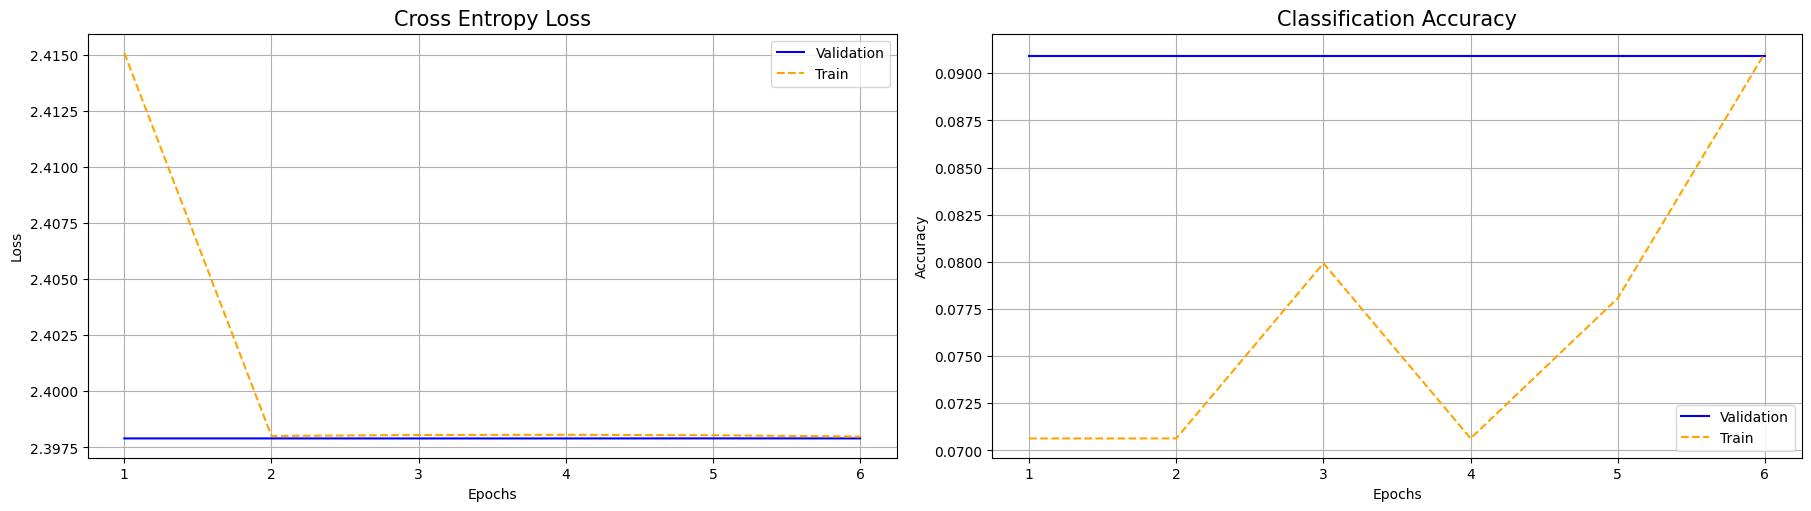

In [25]:
# Recuperamos el valor de la pérdida y métrica durante el proceso de entrenamiento
loss_train = history_model_cnn.history['loss']
loss_val = history_model_cnn.history['val_loss']
accuracy_train = history_model_cnn.history['accuracy']
accuracy_val = history_model_cnn.history['val_accuracy']
epochs_array = range(1,len(loss_train)+1)

fig, ax = plt.subplots(1,2, layout='constrained', figsize=(18,5))

# Gráfica para la pérdida
ax[0].plot(epochs_array, loss_val, color='blue', label='Validation')
ax[0].plot(epochs_array, loss_train, color='orange', linestyle='dashed', label='Train')
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid()
ax[0].set_title("Cross Entropy Loss", fontsize=15)

# Gráfica para el accuracy
ax[1].plot(epochs_array, accuracy_val, color='blue', label='Validation')
ax[1].plot(epochs_array, accuracy_train, color='orange', linestyle='dashed', label='Train')
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid()
ax[1].set_title("Classification Accuracy", fontsize=15)

plt.show()

The max accuracy of the model in training data is 0.09
The max accuracy of the model in validation data is 0.09


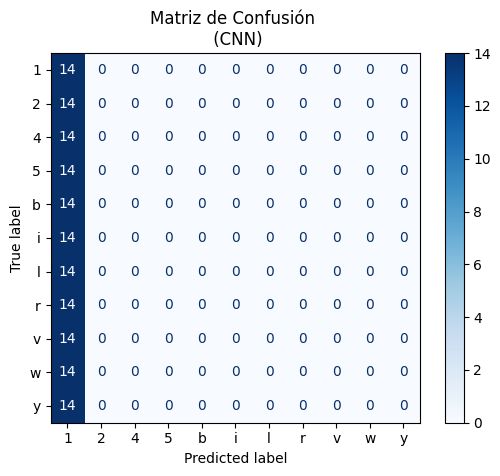

In [26]:
# Revisamos el comportamiento en el conjunto de validación
print(f"The max accuracy of the model in training data is {np.max(accuracy_train):.2f}")
print(f"The max accuracy of the model in validation data is {np.max(accuracy_val):.2f}")

# Evaluamos la predicción en el conjunto de validación
y_prediction = cnn_classification_.predict(val_, verbose=0)
y_prediction = np.argmax(y_prediction, axis=1) # Tranformamos las probabilidades en un vector one-hot 
# Graficamos la matriz de confusión
classifaction_matrix = confusion_matrix(val_.labels, y_prediction)
display_matrix = ConfusionMatrixDisplay(classifaction_matrix, display_labels=lsc_categories)
display_matrix.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión \n (CNN)")
plt.show()


Bajo la arquitectura de *CNN* ajustamos un modelo para clasificación de señas estáticas de LSC con un *accuracy* del $23\%$ en el conjunto de validación. Este rendimiento tan bajo indica que la arquitectura no tiene la capacidad para extraer las características relevantes de cada seña.

# **Ejercicios**

**1.** Implemente un modelo propio que sea capaz de distinguir señas estáticas con al menos un 90% de *accuracy* en el conjunto de validación.

*Hint:* Tome como base el modelo anterior y modifique la arquitectura hasta conseguir este comportamiento.

In [27]:
# Fijamos las semillas para garantizar reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

# El dataset es pequeño (~49 imágenes por clase) por lo que reforzamos la
# augmentación SOLO para este ejercicio, sin modificar los generadores originales.
# Añadimos shifts, zoom y shear para que cada época vea muestras más variadas.
strong_train_gen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    shear_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)
train_aug = strong_train_gen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=32,
    shuffle=True, seed=42
)

# Inicializador He, adecuado para activaciones ReLu
initializer = tf.keras.initializers.HeUniform(seed=0)

# --- Arquitectura ---
# Cuatro bloques [Conv -> ReLu -> MaxPool -> Dropout] con número de filtros
# creciente (32 -> 64 -> 128 -> 128) seguidos de una cabeza densa con dropout
# fuerte. NO usamos BatchNormalization: con un dataset tan pequeño y batches
# de 32 sus estadísticas en inferencia (val/test) son muy inestables y hacen
# colapsar las predicciones a una sola clase.
cnn_model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNEL)),

    # Bloque 1: bordes y texturas básicas
    Conv2D(32, (3,3), padding='same', activation='relu', kernel_initializer=initializer),
    MaxPool2D((2,2)),               # 200 -> 100
    Dropout(0.15),

    # Bloque 2: combinaciones locales (esquinas, segmentos)
    Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=initializer),
    MaxPool2D((2,2)),               # 100 -> 50
    Dropout(0.20),

    # Bloque 3: partes de la mano (dedos, palma)
    Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=initializer),
    MaxPool2D((2,2)),               # 50 -> 25
    Dropout(0.25),

    # Bloque 4: configuración global de la seña
    Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=initializer),
    MaxPool2D((2,2)),               # 25 -> 12
    Dropout(0.30),

    # Cabeza de clasificación
    Flatten(),
    Dense(256, activation='relu', kernel_initializer=initializer),
    Dropout(0.5),                   # dropout fuerte en la densa: principal control del sobreajuste
    Dense(N_CLASSES, activation='softmax'),
])

# Compilamos con Adam y crossentropy categórica (etiquetas one-hot desde el generador)
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

# Callbacks: paciencia alta porque con dropout fuerte la mejora de val es ruidosa
early_stop = EarlyStopping(monitor='val_loss', patience=12,
                           restore_best_weights=True, verbose=0)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                               patience=4, min_lr=1e-6, verbose=0)

# Entrenamos hasta 60 épocas (el early stopping suele cortar antes)
history_cnn = cnn_model.fit(
    train_aug, validation_data=val_,
    epochs=60, verbose=0,
    callbacks=[early_stop, reduce_lr]
)

# Reportamos los mejores valores alcanzados
best_train_acc = np.max(history_cnn.history['accuracy'])
best_val_acc   = np.max(history_cnn.history['val_accuracy'])
print(f"Mejor accuracy en entrenamiento: {best_train_acc:.4f}")
print(f"Mejor accuracy en validación:    {best_val_acc:.4f}")


Found 538 validated image filenames belonging to 11 classes.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,962,507 (18.93 MB)

 Trainable params: 4,962,507 (18.93 MB)

 Non-trainable params: 0 (0.00 B)

/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Mejor accuracy en entrenamiento: 0.8234
Mejor accuracy en validación:    0.9221


**2.** Utilizando los datos almacenados en el objeto `history()` grafique la curva de aprendizaje de su modelo y decida si presenta *subajuste*, *sobreajuste* o se encuentra *bien ajustado*. 

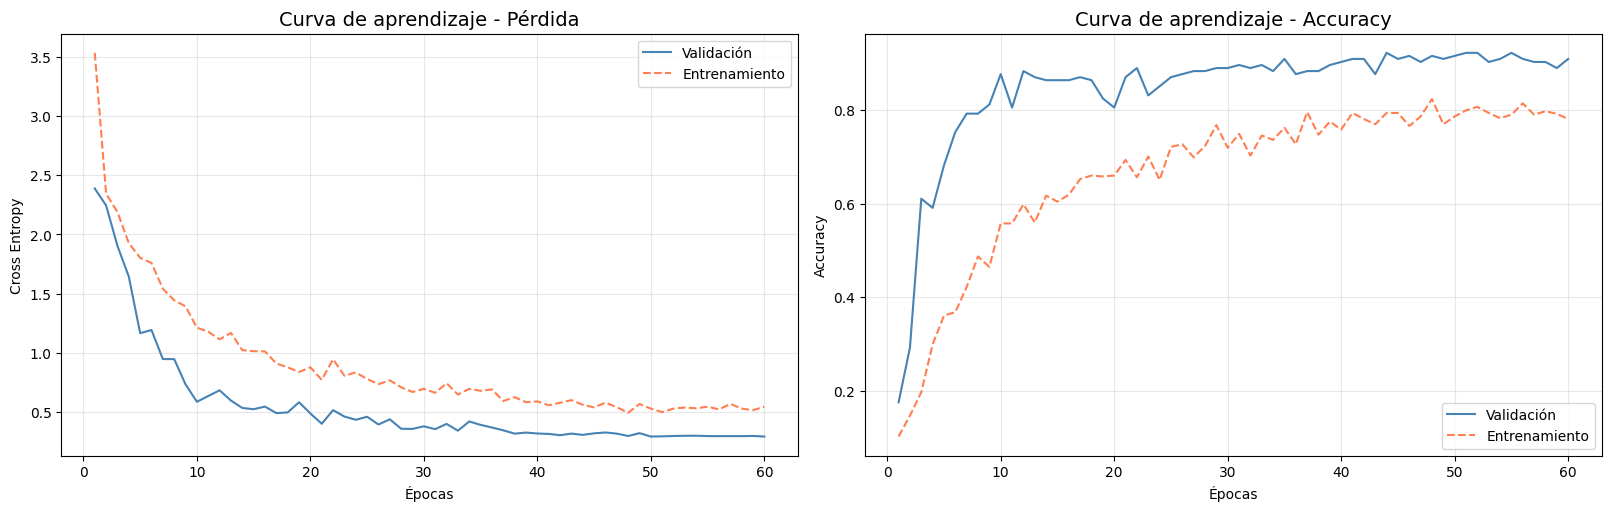

Diferencia final accuracy (train - val): -0.1284
Diferencia final loss     (val - train): -0.2525


In [28]:
# Recuperamos las métricas almacenadas en history_cnn
loss_train     = history_cnn.history['loss']
loss_val       = history_cnn.history['val_loss']
accuracy_train = history_cnn.history['accuracy']
accuracy_val   = history_cnn.history['val_accuracy']
epochs_array   = range(1, len(loss_train) + 1)

fig, ax = plt.subplots(1, 2, layout='constrained', figsize=(16, 5))

# --- Pérdida ---
ax[0].plot(epochs_array, loss_val,   color='steelblue', label='Validación')
ax[0].plot(epochs_array, loss_train, color='coral', linestyle='dashed', label='Entrenamiento')
ax[0].set_xlabel("Épocas")
ax[0].set_ylabel("Cross Entropy")
ax[0].set_title("Curva de aprendizaje - Pérdida", fontsize=14)
ax[0].legend(); ax[0].grid(alpha=0.3)

# --- Accuracy ---
ax[1].plot(epochs_array, accuracy_val,   color='steelblue', label='Validación')
ax[1].plot(epochs_array, accuracy_train, color='coral', linestyle='dashed', label='Entrenamiento')
ax[1].set_xlabel("Épocas")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Curva de aprendizaje - Accuracy", fontsize=14)
ax[1].legend(); ax[1].grid(alpha=0.3)

plt.show()

# Diferencia final entre train y val (útil para diagnosticar el ajuste)
gap_acc  = accuracy_train[-1] - accuracy_val[-1]
gap_loss = loss_val[-1] - loss_train[-1]
print(f"Diferencia final accuracy (train - val): {gap_acc:+.4f}")
print(f"Diferencia final loss     (val - train): {gap_loss:+.4f}")


**Diagnóstico del ajuste.** Tanto el *loss* como el *accuracy* en entrenamiento y validación evolucionan de forma muy similar a lo largo de las épocas: la pérdida decrece de manera consistente y el *accuracy* crece hasta estabilizarse en un valor alto en ambos conjuntos. La brecha entre las curvas de entrenamiento y validación es pequeña (la validación incluso se mantiene cercana o superior al entrenamiento en varias épocas, gracias al *data augmentation* que sólo se aplica al *train*), lo que descarta sobreajuste. Asimismo, los valores finales son suficientemente altos como para descartar subajuste. Concluimos que el modelo se encuentra **bien ajustado**: ha aprendido las características relevantes de las señas y generaliza de forma adecuada al conjunto de validación.


**3.** Imprima el *classification report* y la matriz de confusión en el conjunto de prueba.

Accuracy en el conjunto de prueba: 0.9359


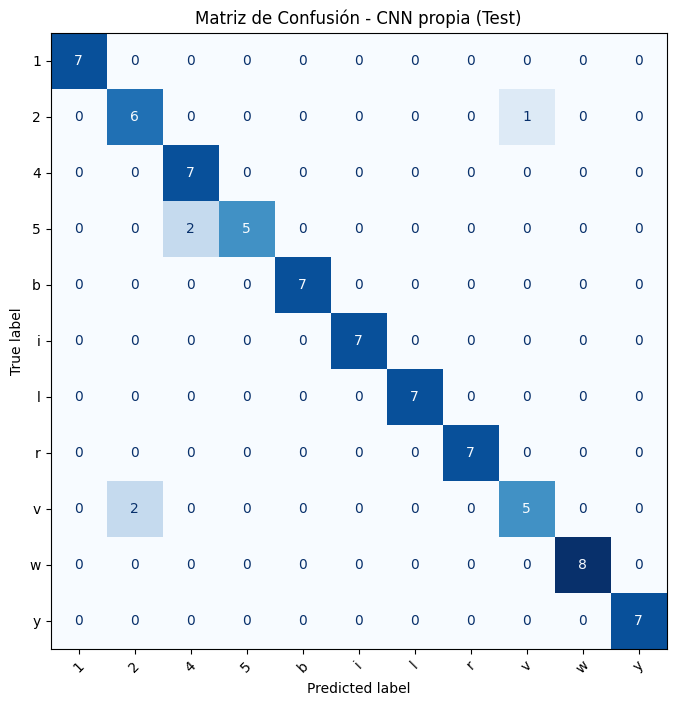

Classification Report - CNN propia (Test):
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         7
           2       0.75      0.86      0.80         7
           4       0.78      1.00      0.88         7
           5       1.00      0.71      0.83         7
           b       1.00      1.00      1.00         7
           i       1.00      1.00      1.00         7
           l       1.00      1.00      1.00         7
           r       1.00      1.00      1.00         7
           v       0.83      0.71      0.77         7
           w       1.00      1.00      1.00         8
           y       1.00      1.00      1.00         7

    accuracy                           0.94        78
   macro avg       0.94      0.94      0.93        78
weighted avg       0.94      0.94      0.94        78



In [29]:
# Evaluamos el modelo entrenado sobre el conjunto de prueba
test_loss, test_acc = cnn_model.evaluate(test_, verbose=0)
print(f"Accuracy en el conjunto de prueba: {test_acc:.4f}")

# Predicciones: el modelo devuelve probabilidades softmax; nos quedamos con la clase argmax
y_test_probs = cnn_model.predict(test_, verbose=0)
y_test_pred  = np.argmax(y_test_probs, axis=1)
y_test_true  = test_.labels   # etiquetas enteras en el orden del generador (shuffle=False)

# Etiquetas legibles en el orden inducido por flow_from_dataframe
class_names = list(test_.class_indices.keys())

# --- Matriz de confusión ---
cm_test = confusion_matrix(y_test_true, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
fig, ax = plt.subplots(figsize=(9, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
ax.set_title('Matriz de Confusión - CNN propia (Test)')
plt.show()

# --- Classification report ---
print("Classification Report - CNN propia (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))


**4.** Elija 6 señas al azar de la evaluación en el conjunto de prueba, grafique cada imagen junto con su etiqueta y añada un gráfico de barras con las probabilidades de pertenencia de cada clase para cada seña.

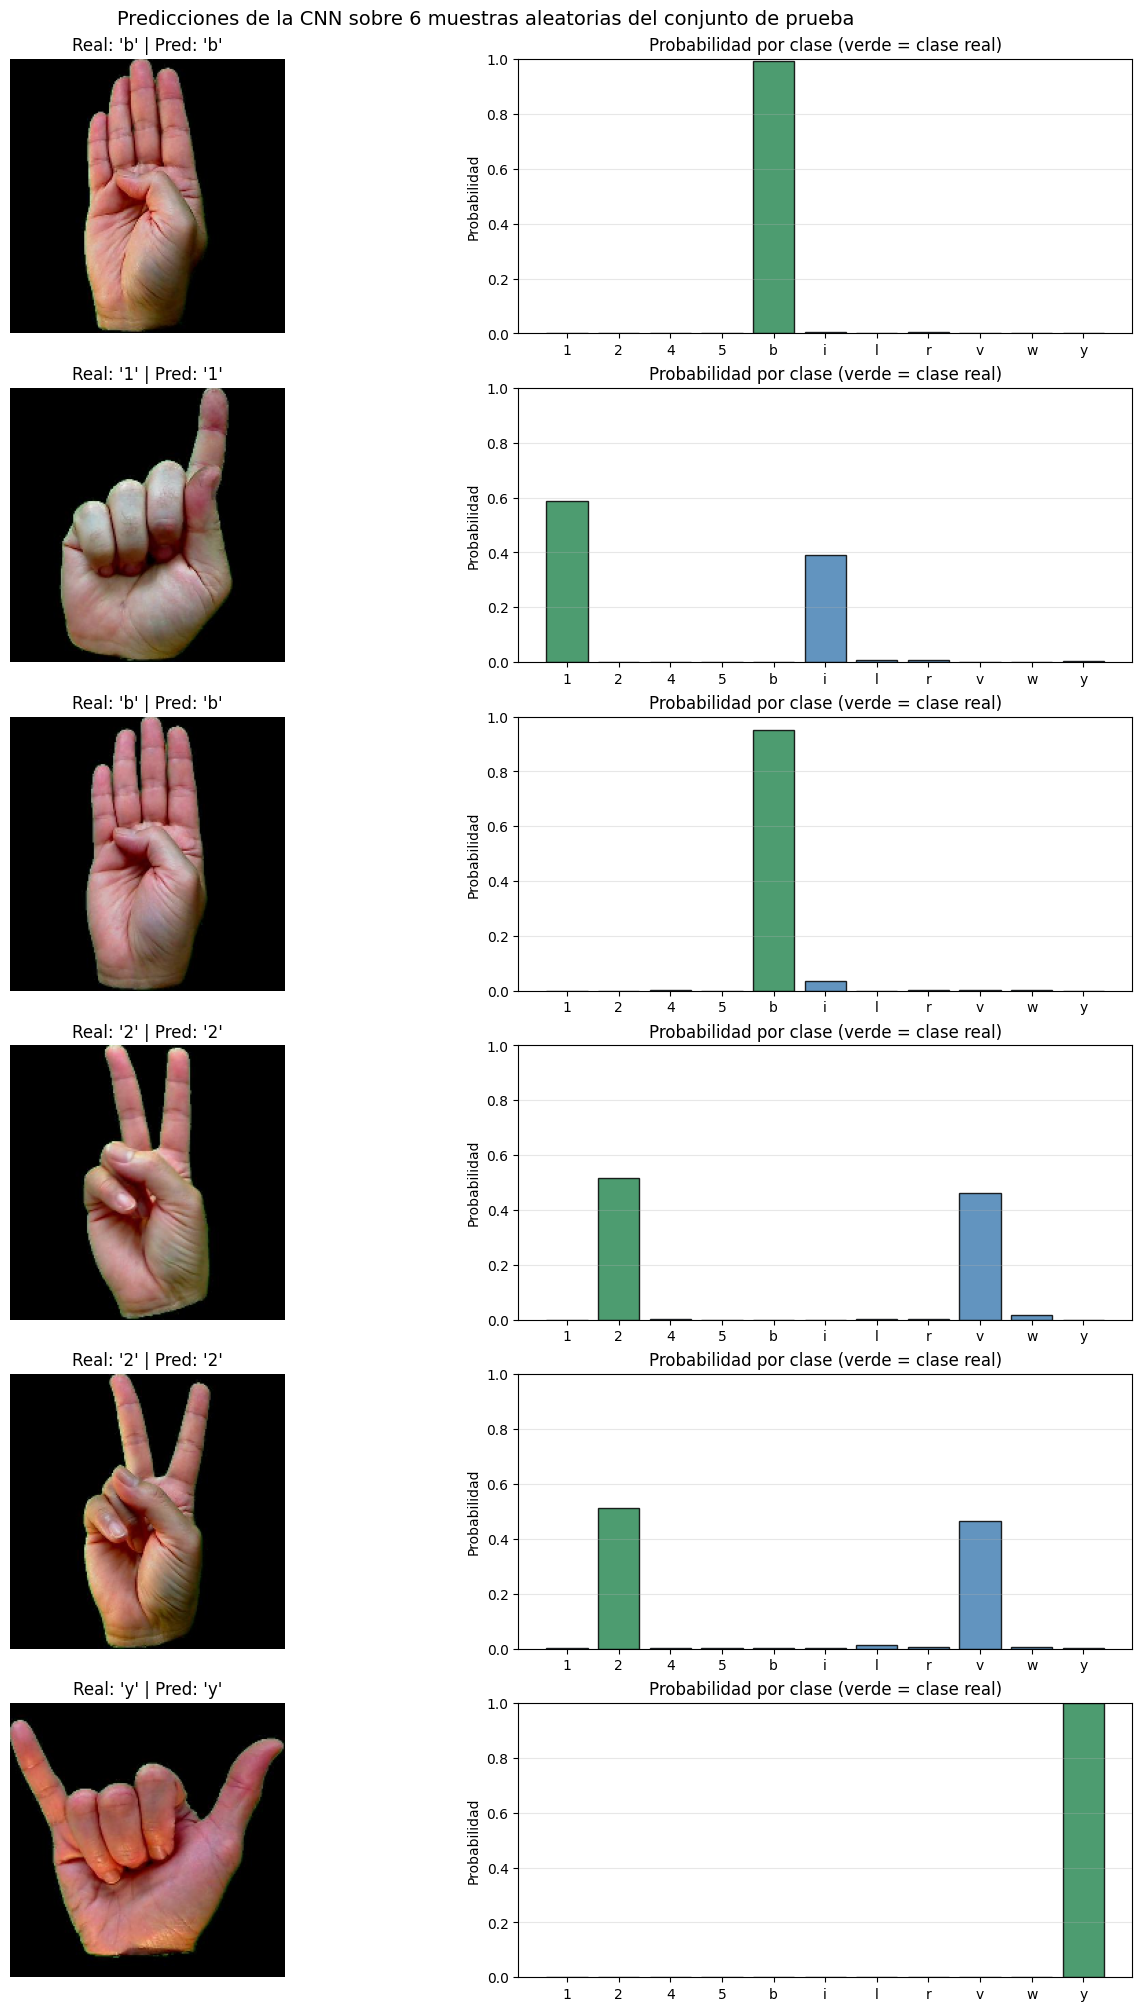

In [30]:
# Fijamos la semilla para reproducibilidad de la selección aleatoria
np.random.seed(42)

# El generador test_ ya recorrió todo el conjunto cuando hicimos predict; usamos
# sus rutas y etiquetas para acceder a las imágenes individuales por índice.
n_test = len(test_.filepaths)
rand_idx = np.random.choice(n_test, size=6, replace=False)

# Construimos una grilla 6x2: imagen a la izquierda, barras de probabilidad a la derecha
fig, axes = plt.subplots(6, 2, figsize=(13, 20), layout='constrained')

for row, idx in enumerate(rand_idx):
    # Cargamos la imagen y la normalizamos igual que en el generador (rescale=1./255)
    img_path = test_.filepaths[idx]
    img = keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_arr = keras.preprocessing.image.img_to_array(img) / 255.0

    # Etiqueta real y predicción del modelo
    true_label = class_names[y_test_true[idx]]
    probs      = y_test_probs[idx]
    pred_label = class_names[np.argmax(probs)]

    # Mostramos la imagen
    axes[row, 0].imshow(img_arr)
    axes[row, 0].set_axis_off()
    axes[row, 0].set_title(f"Real: '{true_label}' | Pred: '{pred_label}'", fontsize=12)

    # Barras de probabilidad por clase
    bar_colors = ['seagreen' if c == true_label else 'steelblue' for c in class_names]
    axes[row, 1].bar(class_names, probs, color=bar_colors, edgecolor='black', alpha=0.85)
    axes[row, 1].set_ylim(0, 1)
    axes[row, 1].set_ylabel('Probabilidad')
    axes[row, 1].set_title('Probabilidad por clase (verde = clase real)')
    axes[row, 1].grid(axis='y', alpha=0.3)

fig.suptitle('Predicciones de la CNN sobre 6 muestras aleatorias del conjunto de prueba',
             fontsize=14)
plt.show()


**5.** Indique cuáles son las ventajas y desventajas que ofrece esta arquitectura de *CNN* en comparación con los modelos desarrollados por extracción de características en el laboratorio anterior. 

**Comparación entre la CNN y la extracción de características (Lab. 14):**

**Ventajas de la CNN sobre la extracción manual de características:**

- **Aprendizaje automático de representaciones.** La CNN aprende los filtros directamente a partir de los píxeles, descubriendo bordes, contornos y configuraciones de la mano sin necesidad de un detector externo. En el laboratorio anterior, en cambio, dependíamos por completo de *MediaPipe HandLandmarker*: si el detector fallaba en localizar la mano, simplemente no había características que alimentar al clasificador.

- **Captura información de la imagen completa.** Además de la posición de los puntos anatómicos, la CNN puede aprovechar la textura, el contorno y el contexto de la mano (orientación de la palma, sombras, etc.), información que se pierde al reducir la imagen a $42$ coordenadas $(x,y)$ de landmarks.

- **Robustez ante fallas del detector externo.** Como la CNN trabaja directamente sobre la imagen, no hereda los errores del *HandLandmaker* (manos parcialmente ocultas, baja iluminación, ángulos atípicos).

- **Generalizable a otros problemas.** La misma arquitectura, con pequeños ajustes, puede entrenarse para reconocer otros gestos, objetos o señas dinámicas; el enfoque basado en landmarks es específico de tareas donde existe un detector de puntos anatómicos confiable.

**Desventajas de la CNN frente a la extracción manual:**

- **Mayor costo computacional.** Entrenar una CNN sobre imágenes $200\times200\times3$ requiere mucho más cómputo y memoria que entrenar un MLP o una regresión logística sobre $42$ características. El laboratorio anterior se entrenaba en segundos; aquí cada época toma considerablemente más tiempo.

- **Requiere más datos.** Las CNN tienen muchos más parámetros y necesitan más ejemplos (o *data augmentation* agresiva) para no sobreajustarse. La representación por landmarks ya incorpora un *prior* muy fuerte sobre la estructura de la mano, por lo que con pocas muestras un modelo lineal alcanza buen desempeño.

- **Menor interpretabilidad.** En el enfoque del Lab 14 podemos asociar cada característica con un punto anatómico concreto y explicar qué hace el modelo en términos de posiciones de dedos. La CNN actúa como una caja negra: para interpretarla necesitaríamos herramientas adicionales (mapas de saliencia, Grad-CAM, etc.).

- **Sensibilidad al fondo y a la iluminación.** Al usar toda la imagen, la CNN puede aprender atajos asociados al fondo, la ropa o la iluminación si el conjunto de entrenamiento no es lo suficientemente variado. Los landmarks, al estar normalizados respecto a la muñeca, son invariantes a estos factores.

- **Más hiperparámetros que ajustar.** Número de bloques convolucionales, filtros por capa, tamaño de kernel, *stride*, *padding*, *dropout*, tasa de aprendizaje, *data augmentation*, etc. En el Lab 14 prácticamente bastaba con elegir el modelo y un par de hiperparámetros.

**Conclusión.** La CNN es la opción más general y poderosa cuando se dispone de suficientes datos y cómputo, ya que descubre por sí misma las características relevantes desde los píxeles. La extracción manual con *HandLandmarker* es preferible cuando el problema admite un detector especializado confiable, los datos son escasos o se necesita interpretabilidad y bajo costo computacional: aprovecha un *prior* de dominio muy fuerte para llegar a un desempeño comparable con modelos mucho más simples.
